### Installing the kaggle library (It's already present in collab but need to be installed on other platforms)

In [ ]:
!pip install kaggle

### Importing the dependencies

In [ ]:
# need these to access our configuration file
# using these in order to read the kaggle file
import os
import json

from zipfile import ZipFile
import pandas as pd # to load the csv file into a pandas dataframe
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Input, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

### Data collection through kaggle API

In [ ]:
kaggle_dictionary = json.load(open('kaggle.json')) # json.load converts a json object into a python dictionary

In [ ]:
kaggle_dictionary.keys() # the dictionary has my username and my kaggle API key

dict_keys(['username', 'key'])

In [ ]:
# setup kaggle credentials as environment variables
# os.environ is a dictionary-like object where you set environment variables
# and these variables can be accessed by the current program and any libraries or child processes running within that environment.
os.environ['KAGGLE_USERNAME'] = kaggle_dictionary['username']
os.environ['KAGGLE_KEY'] = kaggle_dictionary['key']


In [ ]:
# downloading the zip file from kaggle
!kaggle datasets download lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 151MB/s]



In [ ]:
# unzip the dataset file

with ZipFile('imdb-dataset-of-50k-movie-reviews.zip', 'r') as zip_ref: # zif_ref is a variable
  zip_ref.extractall() # extracts all the files within this compressed file

In [ ]:
!ls

'IMDB Dataset.csv'			 kaggle.json
 imdb-dataset-of-50k-movie-reviews.zip	 sample_data


## Loading the dataset

In [ ]:
data = pd.read_csv('IMDB Dataset.csv')

In [ ]:
data.shape

(50000, 2)

In [ ]:
data.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


### Checking if we have any class imbalance

In [ ]:
data['sentiment'].value_counts() # there is no class imbalance

,count
sentiment,
positive,25000
negative,25000


In [ ]:
# encoding the sentiments column

# applying lambda function
data['sentiment'] = data['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# or it can be done this way
# data.replace({'sentiment': {'positive': 1, 'negative': 0}}, inplace=True)

# or it can also be done in this way
# data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
data.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1


### Splitting the data into test and train data

In [ ]:
train_data, test_data = train_test_split(data, test_size = 0.2, random_state = 42)

In [ ]:
print(train_data.shape)
print(test_data.shape)

(40000, 2)
(10000, 2)


# Data preprocessing

First we will tokenize the data

tokenizer converts words to numbers

In [ ]:
tokenizer = Tokenizer(num_words = 5000) # take the most common 5000 words and convert into integers

tokenizer.fit_on_texts(train_data['review']) # fit the tokenizer on the training data, this line assigns indexes

X_train = pad_sequences(tokenizer.texts_to_sequences(train_data['review']), maxlen = 200) # convert the training data into sequences of integers

X_test = pad_sequences(tokenizer.texts_to_sequences(test_data['review']), maxlen = 200) # convert the test data into sequence of integers

# so we're getting all words from the training data and assigning them indexes
# then we're writing the entire data as numbers (tokenizer.texts_to_sequences(train_data['review'])
# and then making the length of each sequence same by padding (200)
# we're not fitting on test data

In [ ]:
print(X_train)

[[1935    1 1200 ...  205  351 3856]
 [   3 1651  595 ...   89  103    9]
 [   0    0    0 ...    2  710   62]
 ...
 [   0    0    0 ... 1641    2  603]
 [   0    0    0 ...  245  103  125]
 [   0    0    0 ...   70   73 2062]]


In [ ]:
y_train = train_data['sentiment']
y_test = test_data['sentiment']

# Building the LSTM model

In [ ]:
model = Sequential()

model.add(Input(shape=(200,)))
model.add(Embedding(input_dim = 5000, output_dim = 128)) # input_dim is the number of words in our vocabulary
model.add(Bidirectional(LSTM(128, dropout = 0.2, recurrent_dropout = 0.2,))) # 128 units, dropouts to prevent overfitting
model.add(Dense(1, activation = 'sigmoid')) # output layer, binary classification so sigmoid

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 903,425 (3.45 MB)

 Trainable params: 903,425 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# complie the model
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

# Training the model

In [ ]:
history = model.fit(X_train, y_train, validation_split = 0.2, epochs = 5, batch_size = 64)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 379s 751ms/step - accuracy: 0.7826 - loss: 0.4582 - val_accuracy: 0.8328 - val_loss: 0.3891
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 361s 723ms/step - accuracy: 0.8528 - loss: 0.3522 - val_accuracy: 0.8404 - val_loss: 0.3573
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 359s 719ms/step - accuracy: 0.8626 - loss: 0.3343 - val_accuracy: 0.8662 - val_loss: 0.3257
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 358s 717ms/step - accuracy: 0.8924 - loss: 0.2701 - val_accuracy: 0.8790 - val_loss: 0.3201
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 382s 718ms/step - accuracy: 0.9032 - loss: 0.2459 - val_accuracy: 0.8674 - val_loss: 0.3176


## Plotting graphs

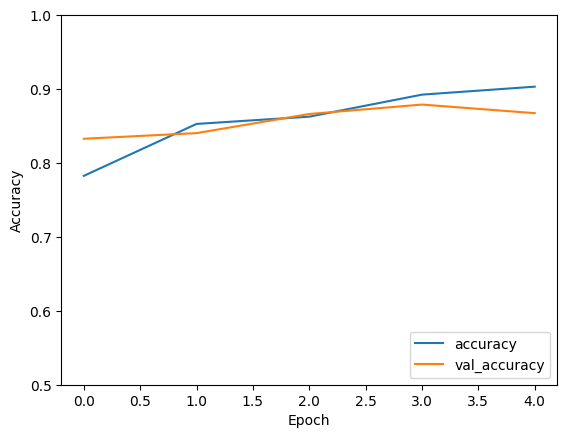

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

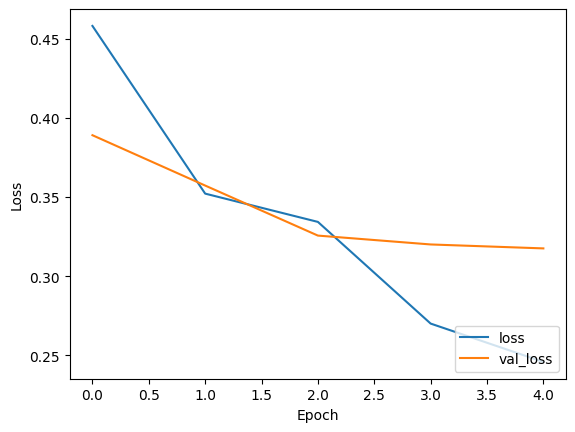

In [ ]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

## Model evaluation

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"test loss = {loss}")
print(f"test accuracy = {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 216ms/step - accuracy: 0.8689 - loss: 0.3076
test loss = 0.30759042501449585
test accuracy = 0.8689000010490417
